In [4]:
import pandas as pd

df = pd.read_excel("/Users/vpgroup/Desktop/GitHub/commodity-demand-analytics/data/raw/Sample_Data.xlsx")

df.shape

(7839, 13)

In [5]:
df["Product"].nunique()
df["Product"].value_counts()

Product
Rice - Basmati           263
Flour - All Purpose      263
Salt - Iodized           263
Spices - Black Pepper    263
Rice - White             262
Wheat - Hard Red         262
Sugar - White Refined    262
Soybean Oil              262
Lentils - Red            262
Coffee - Robusta         262
Pasta - Spaghetti        262
Oats                     262
Yeast - Dry              262
Spices - Turmeric        262
Wheat - Soft             261
Palm Oil                 261
Lentils - Green          261
Chickpeas                261
Tea - Green              261
Coffee - Arabica         261
Cocoa Powder             261
Sugar - Raw Brown        260
Sunflower Oil            260
Corn                     260
Barley                   260
Milk Powder - Whole      260
Milk Powder - Skimmed    260
Tea - Black Ceylon       260
Canned Tuna              260
Canned Tomatoes          260
Name: count, dtype: int64

In [6]:
df.groupby("Product")["Week"].nunique()

Product
Barley                   260
Canned Tomatoes          260
Canned Tuna              260
Chickpeas                260
Cocoa Powder             260
Coffee - Arabica         260
Coffee - Robusta         260
Corn                     260
Flour - All Purpose      260
Lentils - Green          260
Lentils - Red            260
Milk Powder - Skimmed    260
Milk Powder - Whole      260
Oats                     260
Palm Oil                 260
Pasta - Spaghetti        260
Rice - Basmati           260
Rice - White             260
Salt - Iodized           260
Soybean Oil              260
Spices - Black Pepper    260
Spices - Turmeric        260
Sugar - Raw Brown        260
Sugar - White Refined    260
Sunflower Oil            260
Tea - Black Ceylon       260
Tea - Green              260
Wheat - Hard Red         260
Wheat - Soft             260
Yeast - Dry              260
Name: Week, dtype: int64

In [7]:
df.isna().sum().sort_values(ascending=False)

Demand_Forecast             609
Sales_Units                  16
Week                          0
Product                       0
Cost_of_Goods_Sold_COGS       0
Inventory_Level               0
Price_Per_Unit                0
Gross_Profit                  0
Operating_Profit              0
Revenue                       0
Inventory_Turnover_Ratio      0
Gross_Profit_Margin           0
Revenue_Growth                0
dtype: int64

In [9]:
df.describe().T

/Users/vpgroup/Desktop/GitHub/commodity-demand-analytics/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
Week,7839.0,1.305052e+02,75.075517,1.00,65.00000,131.0000,196.00000,260.0000
Sales_Units,7823.0,1.247990e+03,809.602425,0.00,593.00000,1500.0000,1786.00000,3147.0000
Cost_of_Goods_Sold_COGS,7839.0,2.474400e+01,12.499507,5.53,13.39000,23.2900,32.88000,50.8700
Inventory_Level,7839.0,1.495027e+04,35359.292717,0.00,1500.00000,2500.0000,4239.50000,201836.0000
Demand_Forecast,7230.0,2.049301e+03,893.680406,297.00,1396.50000,2066.0000,2662.75000,4910.0000
Price_Per_Unit,7839.0,3.154307e+01,15.978896,6.84,17.13000,29.5300,42.92500,67.6300
Gross_Profit,7839.0,8.699481e+03,8001.518301,0.00,1860.00000,6738.0600,13602.50000,41975.0000
Operating_Profit,7839.0,4.733535e+03,4653.284871,0.00,968.15000,3527.9400,7055.99000,29570.1300
Revenue,7839.0,4.039140e+04,36268.415440,0.00,8809.30500,32790.0000,62830.11000,165050.0000
Inventory_Turnover_Ratio,7839.0,5.361768e-01,0.442782,0.00,0.01000,0.6500,1.00000,1.0000


Revenue=SalesUnits×Price

and approximately:

GrossProfit=Revenue−SalesUnits×COGS

In [12]:
df["revenue_calculated"] = (
    df["Sales_Units"] * df["Price_Per_Unit"]
)

df["revenue_error"] = (
    df["Revenue"] - df["revenue_calculated"]
)

df["revenue_error"].describe()

count    7.823000e+03
mean     2.216915e-14
std      3.716105e-12
min     -2.910383e-11
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.910383e-11
Name: revenue_error, dtype: float64

In [15]:
df["GrossProfit_calculated"] = (
    df["Revenue"] - (df["Sales_Units"] * df["Cost_of_Goods_Sold_COGS"])
)

df["GrossProfit_error"] = (
    df["Gross_Profit"] - df["GrossProfit_calculated"]
)
df["GrossProfit_error"].describe()

count    7.823000e+03
mean    -2.645303e-14
std      3.214377e-12
min     -2.546585e-11
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.910383e-11
Name: GrossProfit_error, dtype: float64

In [16]:
df["demand_gap"] = (
    df["Demand_Forecast"] - df["Sales_Units"]
)
df["demand_gap"].describe()


count    7215.000000
mean      800.675676
std      1074.452737
min      -880.000000
25%        -6.000000
50%       256.000000
75%      1476.000000
max      4686.000000
Name: demand_gap, dtype: float64

In [18]:
print(df["demand_gap"].mean())
print(df["demand_gap"].median())

800.6756756756756
256.0


In [19]:
df.groupby("Product")["demand_gap"].mean()

Product
Barley                   1279.644351
Canned Tomatoes           865.180328
Canned Tuna              1469.740586
Chickpeas                  -9.193416
Cocoa Powder              497.701681
Coffee - Arabica          956.067511
Coffee - Robusta          223.995885
Corn                      935.340336
Flour - All Purpose        -3.367521
Lentils - Green          1552.200820
Lentils - Red             499.016461
Milk Powder - Skimmed    1155.205021
Milk Powder - Whole        -4.686441
Oats                     1148.405858
Palm Oil                  480.752101
Pasta - Spaghetti        1454.737705
Rice - Basmati             36.697095
Rice - White              928.474790
Salt - Iodized           1501.804979
Soybean Oil               844.849372
Spices - Black Pepper     852.337449
Spices - Turmeric           0.222672
Sugar - Raw Brown         630.704641
Sugar - White Refined    1448.427984
Sunflower Oil             -11.696203
Tea - Black Ceylon       1712.008475
Tea - Green               306.

Product: Barley

Trend:
Week
1       952.102266
2       963.027237
3       974.019824
4       985.082053
5       996.215647
          ...     
256    1817.801169
257    1827.471518
258    1837.111198
259    1846.719507
260    1856.295879
Name: trend, Length: 260, dtype: float64

Seasonal:
      seasonal_4  seasonal_52
Week                         
1     155.206042  1528.915179
2     874.146732   647.083578
3    -359.343725   869.632505
4    -577.926581  -947.612426
5     108.730891  -702.260023
...          ...          ...
256   319.320600   381.205389
257  -972.806529 -1020.293716
258   513.787400   117.738009
259   221.112180    87.077717
260   317.476474   945.715600

[260 rows x 2 columns]

Residual:
Week
1        32.776512
2        15.742454
3        15.691397
4       540.456955
5      1097.313485
          ...     
256     -18.327158
257     165.628726
258      31.363393
259    -654.909405
260   -3119.487952
Name: resid, Length: 260, dtype: float64


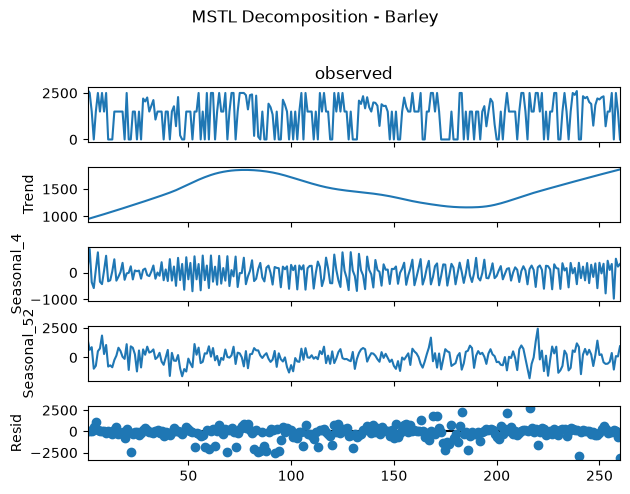

In [23]:
import pandas as pd
from statsmodels.tsa.seasonal import MSTL
import matplotlib.pyplot as plt


# =========================
# 1. Load data
# =========================

df["Sales_Units"] = pd.to_numeric(
    df["Sales_Units"],
    errors="coerce"
)
df["Sales_Units"] = df["Sales_Units"].fillna(0)

df = df.sort_values(["Product", "Week"])

df = df.sort_values(["Product", "Week"])


# =========================
# 2. Run MSTL for each product
# =========================

results = {}

for product, product_df in df.groupby("Product"):

    product_df = product_df.sort_values("Week")

    # Weekly sales series
    y = product_df.set_index("Week")["Sales_Units"]

    # MSTL
    model = MSTL(
        y,
        periods=(52,4),
        stl_kwargs={
            "robust": True
        }
    )

    result = model.fit()

    results[product] = result


# =========================
# 3. Inspect one product
# =========================

product = df["Product"].iloc[0]

result = results[product]

print("Product:", product)
print("\nTrend:")
print(result.trend)

print("\nSeasonal:")
print(result.seasonal)

print("\nResidual:")
print(result.resid)


# =========================
# 4. Plot decomposition
# =========================

result.plot()

plt.suptitle(
    f"MSTL Decomposition - {product}",
    y=1.02
)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import MSTL


# ============================================================
# 1. Prepare data
# ============================================================

df["Week"] = pd.to_numeric(
    df["Week"],
    errors="coerce"
)

df["Sales_Units"] = pd.to_numeric(
    df["Sales_Units"],
    errors="coerce"
)

df = df.dropna(
    subset=["Product", "Week", "Sales_Units"]
)

df["Week"] = df["Week"].astype(int)

df = df.sort_values(
    ["Product", "Week"]
)


# ============================================================
# 2. Define backtesting windows
# ============================================================

windows = [
    ("Window_1", 175, 176, 200),
    ("Window_2", 200, 201, 225),
    ("Window_3", 225, 226, 250),
]


# ============================================================
# 3. Define seasonal periods
# ============================================================

# Seasonal Naive uses annual weekly seasonality
SEASONAL_PERIOD = 52

# MSTL uses:
#   4 weeks  = short-term / approximately monthly seasonality
#   52 weeks = annual seasonality
SEASONAL_PERIODS = (4, 52)


# ============================================================
# 4. Clean and aggregate duplicate Product + Week combinations
# ============================================================

df["Sales_Units"] = pd.to_numeric(
    df["Sales_Units"],
    errors="coerce"
)

df = df.dropna(
    subset=["Sales_Units"]
)

df = (
    df.groupby(
        ["Product", "Week"],
        as_index=False
    )["Sales_Units"]
    .sum()
)

df = df.sort_values(
    ["Product", "Week"]
)

print(df.shape)
print(df.head())


# Check that duplicates have been removed
duplicates = (
    df.groupby(["Product", "Week"])
      .size()
      .reset_index(name="Count")
)

print(
    duplicates[duplicates["Count"] > 1]
)


# ============================================================
# 5. Generate predictions
# ============================================================

predictions = []


for product, product_df in df.groupby("Product"):

    product_df = (
        product_df
        .sort_values("Week")
        .set_index("Week")
    )

    sales = product_df["Sales_Units"].astype(float)


    for window_name, train_end, test_start, test_end in windows:

        # --------------------------------
        # Training data
        # --------------------------------

        train = sales.loc[1:train_end]

        horizon = test_end - test_start + 1

        # ====================================================
        # MSTL
        # ====================================================

        mstl = MSTL(
            train,
            periods=SEASONAL_PERIODS,
            stl_kwargs={"robust": True},
        )

        mstl_result = mstl.fit()


        # --------------------------------
        # Extract trend
        # --------------------------------

        trend = mstl_result.trend.dropna()


        # --------------------------------
        # Forecast trend
        # --------------------------------

        trend_window = min(
            SEASONAL_PERIOD,
            len(trend)
        )

        x = np.arange(
            trend_window
        )

        y = trend.iloc[
            -trend_window:
        ].values

        slope, intercept = np.polyfit(
            x,
            y,
            1
        )

        future_x = np.arange(
            trend_window,
            trend_window + horizon,
        )

        future_trend = (
            intercept
            + slope * future_x
        )


        # ====================================================
        # Forecast seasonal components
        # ====================================================

        future_seasonal = np.zeros(
            horizon
        )


        # --------------------------------
        # 4-week seasonality
        # --------------------------------

        seasonal_4 = (
            mstl_result
            .seasonal["seasonal_4"]
        )

        seasonal_pattern_4 = (
            seasonal_4
            .iloc[-4:]
            .to_numpy()
        )

        future_seasonal_4 = np.resize(
            seasonal_pattern_4,
            horizon
        )


        # --------------------------------
        # 52-week seasonality
        # --------------------------------

        seasonal_52 = (
            mstl_result
            .seasonal["seasonal_52"]
        )

        seasonal_pattern_52 = (
            seasonal_52
            .iloc[-52:]
            .to_numpy()
        )

        future_seasonal_52 = np.resize(
            seasonal_pattern_52,
            horizon
        )


        # --------------------------------
        # Combine seasonal components
        # --------------------------------

        future_seasonal = (
            future_seasonal_4
            + future_seasonal_52
        )


        # ====================================================
        # Reconstruct MSTL forecast
        # ====================================================

        mstl_forecast = (
            future_trend
            + future_seasonal
        )


        # ====================================================
        # Store predictions
        # ====================================================

        for i, week in enumerate(
            range(
                test_start,
                test_end + 1
            )
        ):

            # --------------------------------
            # Seasonal Naive
            # --------------------------------

            lag_week = (
                week
                - SEASONAL_PERIOD
            )

            actual = float(
                sales.loc[week]
            )

            seasonal_naive = float(
                sales.loc[lag_week]
            )


            # --------------------------------
            # MSTL
            # --------------------------------

            mstl_predicted = float(
                mstl_forecast[i]
            )


            # --------------------------------
            # Save
            # --------------------------------

            predictions.append({
                "Product": product,
                "Window": window_name,
                "Train_End": train_end,
                "Week": week,
                "Actual": actual,
                "Seasonal_Naive": seasonal_naive,
                "MSTL": mstl_predicted,
            })


# ============================================================
# 6. Prediction dataframe
# ============================================================

pred_df = pd.DataFrame(
    predictions
)


# Force numeric types

pred_df["Actual"] = pd.to_numeric(
    pred_df["Actual"],
    errors="coerce"
)

pred_df["Seasonal_Naive"] = pd.to_numeric(
    pred_df["Seasonal_Naive"],
    errors="coerce"
)

pred_df["MSTL"] = pd.to_numeric(
    pred_df["MSTL"],
    errors="coerce"
)


# ============================================================
# 7. Calculate errors
# ============================================================

pred_df["SN_Error"] = (
    pred_df["Seasonal_Naive"]
    - pred_df["Actual"]
)

pred_df["MSTL_Error"] = (
    pred_df["MSTL"]
    - pred_df["Actual"]
)

pred_df["SN_Absolute_Error"] = (
    pred_df["SN_Error"].abs()
)

pred_df["MSTL_Absolute_Error"] = (
    pred_df["MSTL_Error"].abs()
)

pred_df["SN_Squared_Error"] = (
    pred_df["SN_Error"] ** 2
)

pred_df["MSTL_Squared_Error"] = (
    pred_df["MSTL_Error"] ** 2
)


# ============================================================
# 8. Calculate metrics
# ============================================================

metrics_list = []


for (product, window), group in pred_df.groupby(
    ["Product", "Window"]
):

    actual = group[
        "Actual"
    ].to_numpy(dtype=float)

    SN_predicted = group[
        "Seasonal_Naive"
    ].to_numpy(dtype=float)

    MSTL_predicted = group[
        "MSTL"
    ].to_numpy(dtype=float)


    # ========================================================
    # Seasonal Naive
    # ========================================================

    SN_error = (
        SN_predicted
        - actual
    )

    SN_mae = np.mean(
        np.abs(SN_error)
    )

    SN_rmse = np.sqrt(
        np.mean(
            SN_error ** 2
        )
    )

    denominator = np.sum(
        np.abs(actual)
    )

    if denominator != 0:

        SN_wape = (
            np.sum(
                np.abs(SN_error)
            )
            / denominator
        ) * 100

    else:

        SN_wape = np.nan


    SN_bias = np.mean(
        SN_error
    )


    # ========================================================
    # MSTL
    # ========================================================

    MSTL_error = (
        MSTL_predicted
        - actual
    )

    MSTL_mae = np.mean(
        np.abs(MSTL_error)
    )

    MSTL_rmse = np.sqrt(
        np.mean(
            MSTL_error ** 2
        )
    )

    denominator = np.sum(
        np.abs(actual)
    )

    if denominator != 0:

        MSTL_wape = (
            np.sum(
                np.abs(MSTL_error)
            )
            / denominator
        ) * 100

    else:

        MSTL_wape = np.nan


    MSTL_bias = np.mean(
        MSTL_error
    )


    # ========================================================
    # Store metrics
    # ========================================================

    metrics_list.append({

        "Product": product,
        "Window": window,

        "SN_MAE": SN_mae,
        "MSTL_MAE": MSTL_mae,

        "SN_RMSE": SN_rmse,
        "MSTL_RMSE": MSTL_rmse,

        "SN_WAPE": SN_wape,
        "MSTL_WAPE": MSTL_wape,

        "SN_Bias": SN_bias,
        "MSTL_Bias": MSTL_bias,

        "Actual_Total": np.sum(
            actual
        ),

        "SN_Predicted_Total": np.sum(
            SN_predicted
        ),

        "MSTL_Predicted_Total": np.sum(
            MSTL_predicted
        ),
    })


metrics = pd.DataFrame(
    metrics_list
)


# ============================================================
# 9. Plot actual vs predicted for each product
# ============================================================

for product in pred_df[
    "Product"
].unique():

    product_pred = (
        pred_df[
            pred_df["Product"] == product
        ]
        .sort_values("Week")
    )


    plt.figure(
        figsize=(14, 6)
    )


    # --------------------------------
    # Actual
    # --------------------------------

    plt.plot(
        product_pred["Week"],
        product_pred["Actual"],
        label="Actual",
        linewidth=2
    )


    # --------------------------------
    # Seasonal Naive
    # --------------------------------

    plt.plot(
        product_pred["Week"],
        product_pred["Seasonal_Naive"],
        label="Seasonal Naive",
        linestyle="--",
        linewidth=2
    )


    # --------------------------------
    # MSTL
    # --------------------------------

    plt.plot(
        product_pred["Week"],
        product_pred["MSTL"],
        label="MSTL (4, 52)",
        linestyle=":",
        linewidth=2,
    )


    # --------------------------------
    # Window boundaries
    # --------------------------------

    plt.axvline(
        175,
        linestyle="--",
        alpha=0.5,
    )

    plt.axvline(
        200,
        linestyle="--",
        alpha=0.5,
    )

    plt.axvline(
        225,
        linestyle="--",
        alpha=0.5,
    )


    # --------------------------------
    # Test-window boundaries
    # --------------------------------

    plt.axvline(
        x=200.5,
        linestyle=":",
        linewidth=1
    )

    plt.axvline(
        x=225.5,
        linestyle=":",
        linewidth=1
    )


    # --------------------------------
    # Labels
    # --------------------------------

    plt.title(
        f"{product} - Seasonal Naive vs MSTL (4, 52)"
    )

    plt.xlabel(
        "Week"
    )

    plt.ylabel(
        "Sales Units"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

(7800, 3)
  Product  Week  Sales_Units
0  Barley     1       2669.0
1  Barley     2       2500.0
2  Barley     3       1500.0
3  Barley     4          0.0
4  Barley     5       1500.0
Empty DataFrame
Columns: [Product, Week, Count]
Index: []
<class 'pandas.DataFrame'>
(175, 2)
Index(['seasonal_4', 'seasonal_52'], dtype='str')
       seasonal_4  seasonal_52
Week                          
1      116.047767   443.258838
2     1034.847517   321.780716
3     -210.828169   569.458416
4     -865.727357  -288.728120
5      104.764671   245.518503


KeyError: 4